• 20% of training data (low-data regime)

• 50% of training data (moderate regime)

• 100% of training data (full-data regime)

• Resize images to 224 × 224

• Normalize based on model requirements 

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR='Dataset'

print(DEVICE)

cuda


In [2]:
def loaddata(split=0.7,batchsize=16):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        # transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    #==========================
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    if len(dataset) == 0: raise ValueError(f"No images found in the dataset directory: {DATA_DIR}. Please ensure it contains class subdirectories with images.")

    total_samples = len(dataset)

    train_size = int(split * total_samples)
    val_size = int( ((1-split)/2) * total_samples)
    test_size = total_samples - train_size - val_size

    adjusted_sizes = [train_size, val_size, test_size]
    current_sum = sum(adjusted_sizes)

    if current_sum != total_samples:
        diff = total_samples - current_sum
        test_size = max(0, test_size + diff)

    if total_samples > 0:
        if train_size == 0 and total_samples > 0: train_size = 1
        if val_size == 0 and total_samples - train_size > 0: val_size = 1
        if test_size == 0 and total_samples - train_size - val_size > 0: test_size = 1

        current_sum = train_size + val_size + test_size
        if current_sum > total_samples:
            test_size = max(0, test_size - (current_sum - total_samples))
        elif current_sum < total_samples:

            test_size += (total_samples - current_sum)

        train_size = max(0, train_size)
        val_size = max(0, val_size)
        test_size = max(0, test_size)
    else:
        train_size, val_size, test_size = 0, 0, 0

    if total_samples == 0:
        train_data, val_data, test_data = [], [], []
    elif total_samples == 1:
        train_data, val_data, test_data = random_split(dataset, [1, 0, 0])
    elif total_samples == 2:
        train_data, val_data, test_data = random_split(dataset, [1, 1, 0])
    elif total_samples == 3:
        train_data, val_data, test_data = random_split(dataset, [1, 1, 1])
    else:
        train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])


    print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)} (Total: {total_samples})")

    train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batchsize)
    test_loader = DataLoader(test_data, batch_size=batchsize)

    print("Classes:", dataset.classes)
    return dataset.classes,  train_loader,val_loader,test_loader

#===============
loaddata()

Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']


(['Knee OA', 'No-Knee OA'],
 <torch.utils.data.dataloader.DataLoader at 0x159af22a350>)

Model

In [3]:
#load DinoV2 model
#MLP classifier
#    Linear → ReLU → Dropout → Linear → Softmax
import torch
# from dinov2.models import build_model_from_cfg
# from dinov2.configs import load_and_merge_config

class HIdino(torch.nn.Module):
    def __init__(self,unfrozen=False):
        super(HIdino, self).__init__()
        # cfg = load_and_merge_config("eval/vits14_pretrain")
        # self.basemodel, teacher, FeatureSize= build_model_from_cfg(cfg)
        # self.modelHead = self.basemodel.head    #backupcopy
        # self.basemodel.head = torch.nn.Identity()  # remove classification head
        self.basemodel = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(DEVICE)
        self.modelHead = getattr(self.basemodel, "head", None)
        if hasattr(self.basemodel, "head"): self.basemodel.head = nn.Identity()
        
        if unfrozen:
            for param in self.basemodel.parameters():
                param.require_grad = True
        else:
            for param in self.basemodel.parameters():
                param.require_grad = False
        
        # FeatureSize = self.basemodel.embed_dim
        # print(FeatureSize)
        #----
        self.merge_head = torch.nn.Sequential(
                            torch.nn.LayerNorm(384),
                            torch.nn.Linear(384, 128),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(0.3),
                            torch.nn.Linear(128, 1),
                            # torch.nn.Softmax(dim=1)
                            ).to(DEVICE)
    #===========
    def forward(self,Imgs):
        # print('Imgs',Imgs.shape)
        imgFeat= self.basemodel(Imgs.to(DEVICE))#.unsqueeze(1).to(DEVICE)
        # print('imgFeat',imgFeat.shape)
        return self.merge_head(imgFeat).squeeze(1).float().to(DEVICE)
# HIdino()

• Loss: Cross-Entropy

• Optimizer: AdamW

• Batch size: 16 (recommended)

• Epochs: 10–20

• Early stopping based on validation

[DO FOR 20 50 100 % split]

• Accuracy

• Precision

• Recall

• F1-score

• Macro-F1 (important)

• ROC-AUC

In [4]:
def runmodel(split=0.7,batchsize=16,epochs=10,learnrate=0.001,unfrozen=False):
    model = HIdino(unfrozen)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnrate)
    classes,train_loader,val_loader,test_loader = loaddata(split,batchsize)
    
    #===================
    #Train
    #===================
    train_losses = [];val_losses = []
    if len(train_loader) > 0:
        for epoch in range(epochs):
            model.train()
            running_loss = 0
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                optimizer.zero_grad()
                outputs = model(images)
                # print(outputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            train_loss = running_loss / len(train_loader)
            train_losses.append(train_loss)
            
            #------
            #validation
            model.eval()
            val_loss = 0
            if len(val_loader) > 0:
                with torch.no_grad():
                    for images, labels in val_loader:
                        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                val_loss /= len(val_loader)
                val_losses.append(val_loss)
            else:
                val_losses.append(None)
                print("No validation data available for this epoch.")

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss if val_loss is not None else 'N/A' :.4f}")
    else: print(" No training data available. Skipping training loop.")
    
    #===================
    #Test
    #===================
    model.eval()
    all_preds = []
    all_labels = []

    if len(test_loader) > 0:
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                # _, preds = torch.max(outputs, 1)
                preds=torch.sigmoid(outputs)
                preds = (preds>=0.5).float()
                # print(preds)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        if len(all_labels) > 0:
            print("\nConfusion Matrix:")
            cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(classes)))
            
            plt.clf()
            plt.figure()
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix")
            plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___CM.png")
            # plt.show()

            print("\nClassification Report:")
            print(classification_report(all_labels, all_preds, target_names=classes, labels=np.arange(len(classes))))
        else: print("Test data loader was not empty, but no predictions or labels were collected.")
    else: print("No test data available.")
    
    #===================
    #Loss Curve
    #===================
    valid_val_losses = [l for l in val_losses if l is not None]

    if train_losses or valid_val_losses:
        plt.clf()
        plt.figure()
        plt.plot(train_losses, label="Train Loss")
        plt.plot(valid_val_losses, label="Validation Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___LC.png")
        # plt.show()
    else: print("No loss data to plot.")
    
    #===================
    #ROC Curve
    #===================
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_preds)
    print("ROC-AUC:", auc_score)

    # Plot ROC curve
    plt.clf()
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___ROC.png")
    # plt.show()
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001)
# runmodel(split=0.7,batchsize=16,epochs=3,learnrate=0.0000001)
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001,unfrozen=False)
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001,unfrozen=True)

Remake, dont use a validation or testing split

In [5]:
def runmodel_final(split=0.7,batchsize=16,epochs=10,learnrate=0.001,unfrozen=False):
    model = HIdino(unfrozen)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnrate)
    classes,train_loader,val_loader,test_loader = loaddata(split,batchsize)
    
    #===================
    #Train
    #===================
    train_losses = [];val_losses = []
    if len(train_loader) > 0:
        for epoch in range(epochs):
            model.train()
            running_loss = 0
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                optimizer.zero_grad()
                outputs = model(images)
                # print(outputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            train_loss = running_loss / len(train_loader)
            train_losses.append(train_loss)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}")
    else: print(" No training data available. Skipping training loop.")
    
    #===================
    #Test - still training
    #===================
    model.eval()
    all_preds = []
    all_labels = []

    if len(test_loader) > 0:
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                # _, preds = torch.max(outputs, 1)
                preds=torch.sigmoid(outputs)
                preds = (preds>=0.5).float()
                # print(preds)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        if len(all_labels) > 0:
            print("\nConfusion Matrix:")
            cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(classes)))
            
            plt.clf()
            plt.figure()
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix")
            plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___CM.png")
            # plt.show()

            print("\nClassification Report:")
            print(classification_report(all_labels, all_preds, target_names=classes, labels=np.arange(len(classes))))
        else: print("Test data loader was not empty, but no predictions or labels were collected.")
    else: print("No test data available.")
    
    #===================
    #Loss Curve
    #===================
    valid_val_losses = [l for l in val_losses if l is not None]

    if train_losses or valid_val_losses:
        plt.clf()
        plt.figure()
        plt.plot(train_losses, label="Train Loss")
        # plt.plot(valid_val_losses, label="Validation Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___LC.png")
        # plt.show()
    else: print("No loss data to plot.")
    
    #===================
    #ROC Curve
    #===================
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_preds)
    print("ROC-AUC:", auc_score)

    # Plot ROC curve
    plt.clf()
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___ROC.png")
    # plt.show()
# runmodel_final(split=0.7,batchsize=16,epochs=3,learnrate=0.001)

# table 2

frozen

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Train: 831, Val: 1662, Test: 1663 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 30.4652
Epoch 2/20 | Train Loss: 29.6130
Epoch 3/20 | Train Loss: 29.0527
Epoch 4/20 | Train Loss: 28.8601
Epoch 5/20 | Train Loss: 28.3961
Epoch 6/20 | Train Loss: 28.1870
Epoch 7/20 | Train Loss: 27.9778
Epoch 8/20 | Train Loss: 27.9338
Epoch 9/20 | Train Loss: 28.0220
Epoch 10/20 | Train Loss: 27.7367
Epoch 11/20 | Train Loss: 27.5368
Epoch 12/20 | Train Loss: 27.5234
Epoch 13/20 | Train Loss: 27.5154
Epoch 14/20 | Train Loss: 27.4825
Epoch 15/20 | Train Loss: 27.3622
Epoch 16/20 | Train Loss: 27.4798
Epoch 17/20 | Train Loss: 27.4655
Epoch 18/20 | Train Loss: 27.3907
Epoch 19/20 | Train Loss: 27.4142
Epoch 20/20 | Train Loss: 27.3653

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       0.99      0.98      0.98       253
  No-Knee OA       0.99      0.99      0.99       578

    accuracy                           

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 1246, Val: 1454, Test: 1456 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 30.6293
Epoch 2/20 | Train Loss: 29.4050
Epoch 3/20 | Train Loss: 28.9640
Epoch 4/20 | Train Loss: 28.5692
Epoch 5/20 | Train Loss: 28.5491
Epoch 6/20 | Train Loss: 28.5806
Epoch 7/20 | Train Loss: 28.4119
Epoch 8/20 | Train Loss: 28.3541
Epoch 9/20 | Train Loss: 28.1255
Epoch 10/20 | Train Loss: 28.1127
Epoch 11/20 | Train Loss: 27.9793
Epoch 12/20 | Train Loss: 28.0367
Epoch 13/20 | Train Loss: 27.9392
Epoch 14/20 | Train Loss: 27.9467
Epoch 15/20 | Train Loss: 28.1254
Epoch 16/20 | Train Loss: 27.8316
Epoch 17/20 | Train Loss: 27.7325
Epoch 18/20 | Train Loss: 27.8135
Epoch 19/20 | Train Loss: 28.0079
Epoch 20/20 | Train Loss: 27.7922

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       0.99      0.96      0.98       369
  No-Knee OA       0.98      1.00      0.99       877

    accuracy                          

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

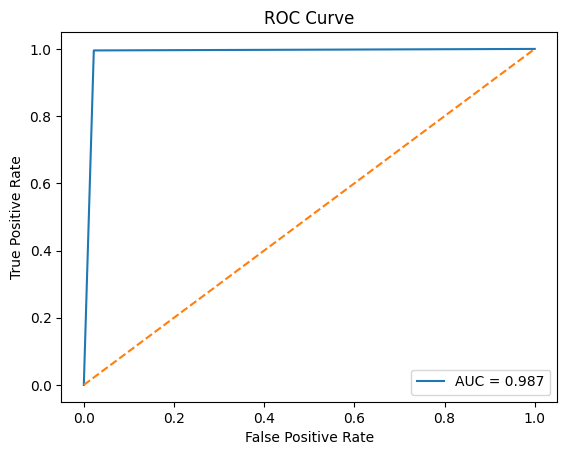

In [6]:
#   20/30/40/50/60/70/80/90/100
runmodel_final(split=0.2,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.3,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.4,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.5,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.6,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.7,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.8,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.9,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel_final(split=0.99,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 4156, Val: 0, Test: 0 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.6284
Epoch 2/20 | Train Loss: 28.5959
Epoch 3/20 | Train Loss: 28.3214
Epoch 4/20 | Train Loss: 28.1799
Epoch 5/20 | Train Loss: 27.9966
Epoch 6/20 | Train Loss: 27.9474
Epoch 7/20 | Train Loss: 27.8694
Epoch 8/20 | Train Loss: 27.9158
Epoch 9/20 | Train Loss: 27.8243
Epoch 10/20 | Train Loss: 27.8492
Epoch 11/20 | Train Loss: 27.7559
Epoch 12/20 | Train Loss: 27.7429
Epoch 13/20 | Train Loss: 27.6806
Epoch 14/20 | Train Loss: 27.7448
Epoch 15/20 | Train Loss: 27.6856
Epoch 16/20 | Train Loss: 27.7222
Epoch 17/20 | Train Loss: 27.6935
Epoch 18/20 | Train Loss: 27.6205
Epoch 19/20 | Train Loss: 27.6251
Epoch 20/20 | Train Loss: 27.6266
No test data available.
nope


ValueError: y_true takes value in {} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

<Figure size 640x480 with 0 Axes>

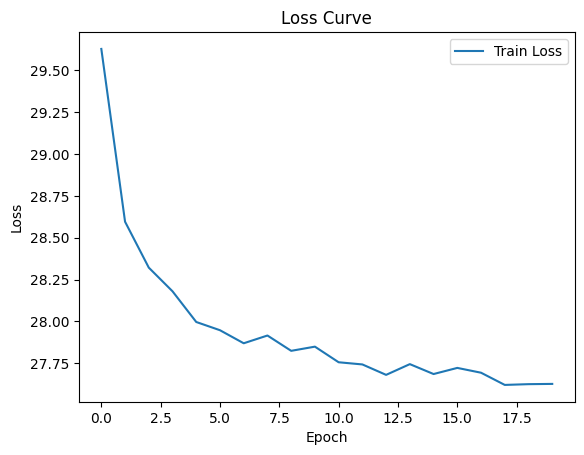

In [7]:
try:
    runmodel_final(split=1,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
except Exception as e:
    print('nope')
    raise(e)

unfrozen

In [ ]:
#   20/30/40/50/60/70/80/90/100
runmodel_final(split=0.2,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.3,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.4,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.5,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.6,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.7,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.8,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.9,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel_final(split=0.99,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 831, Val: 1662, Test: 1663 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.6104
Epoch 2/20 | Train Loss: 29.0865
Epoch 3/20 | Train Loss: 28.4360
Epoch 4/20 | Train Loss: 28.7813
Epoch 5/20 | Train Loss: 27.9088
Epoch 6/20 | Train Loss: 27.9885
Epoch 7/20 | Train Loss: 28.5901
Epoch 8/20 | Train Loss: 30.1458
Epoch 9/20 | Train Loss: 28.6132
Epoch 10/20 | Train Loss: 28.0519
Epoch 11/20 | Train Loss: 28.0221
Epoch 12/20 | Train Loss: 27.9982
Epoch 13/20 | Train Loss: 27.8938
Epoch 14/20 | Train Loss: 27.7205
Epoch 15/20 | Train Loss: 27.8105
Epoch 16/20 | Train Loss: 27.7707
Epoch 17/20 | Train Loss: 27.8662
Epoch 18/20 | Train Loss: 27.7317
Epoch 19/20 | Train Loss: 27.9803
Epoch 20/20 | Train Loss: 27.5230

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       0.98      0.95      0.96       251
  No-Knee OA       0.98      0.99      0.98       580

    accuracy                           

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 1246, Val: 1454, Test: 1456 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.3609
Epoch 2/20 | Train Loss: 28.6098
Epoch 3/20 | Train Loss: 28.1670
Epoch 4/20 | Train Loss: 28.0339
Epoch 5/20 | Train Loss: 28.0055
Epoch 6/20 | Train Loss: 27.7479
Epoch 7/20 | Train Loss: 27.5085
Epoch 8/20 | Train Loss: 27.7010
Epoch 9/20 | Train Loss: 27.5947
Epoch 10/20 | Train Loss: 27.9209
Epoch 11/20 | Train Loss: 27.4694
Epoch 12/20 | Train Loss: 27.5319
Epoch 13/20 | Train Loss: 27.4663
Epoch 14/20 | Train Loss: 27.5290
Epoch 15/20 | Train Loss: 27.4434
Epoch 16/20 | Train Loss: 27.1951
Epoch 17/20 | Train Loss: 27.5362
Epoch 18/20 | Train Loss: 27.5147
Epoch 19/20 | Train Loss: 27.3064
Epoch 20/20 | Train Loss: 27.4007

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       0.82      0.99      0.89       382
  No-Knee OA       1.00      0.90      0.95       864

    accuracy                          

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


...

Train: 3324, Val: 415, Test: 417 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.7635
Epoch 2/20 | Train Loss: 28.7514
Epoch 3/20 | Train Loss: 28.4117
Epoch 4/20 | Train Loss: 28.2796
Epoch 5/20 | Train Loss: 28.1832
Epoch 6/20 | Train Loss: 28.2169
Epoch 7/20 | Train Loss: 28.1042
Epoch 8/20 | Train Loss: 28.3410
Epoch 9/20 | Train Loss: 28.2371
Epoch 10/20 | Train Loss: 28.0739
Epoch 11/20 | Train Loss: 28.2202
Epoch 12/20 | Train Loss: 28.2308
Epoch 13/20 | Train Loss: 27.9329
Epoch 14/20 | Train Loss: 27.8646
Epoch 15/20 | Train Loss: 27.9729
Epoch 16/20 | Train Loss: 27.9323
Epoch 17/20 | Train Loss: 27.8641
Epoch 18/20 | Train Loss: 27.8312
Epoch 19/20 | Train Loss: 27.8823
Epoch 20/20 | Train Loss: 27.8110

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       0.80      0.99      0.89       979
  No-Knee OA       1.00      0.90      0.95      2345

    accuracy                           0

C:\Users\jump3\AppData\Local\Temp\ipykernel_7920\4194724791.py:76: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()
Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 3740, Val: 207, Test: 209 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.4118
Epoch 2/20 | Train Loss: 28.3971
Epoch 3/20 | Train Loss: 28.2935
Epoch 4/20 | Train Loss: 28.0720
Epoch 5/20 | Train Loss: 27.9159
Epoch 6/20 | Train Loss: 27.9872
Epoch 7/20 | Train Loss: 27.9794
Epoch 8/20 | Train Loss: 28.1178
Epoch 9/20 | Train Loss: 28.1829
Epoch 10/20 | Train Loss: 27.8417
Epoch 11/20 | Train Loss: 27.7791
Epoch 12/20 | Train Loss: 27.8031
Epoch 13/20 | Train Loss: 27.7555
Epoch 14/20 | Train Loss: 27.8332
Epoch 15/20 | Train Loss: 27.7084
Epoch 16/20 | Train Loss: 27.8783
Epoch 17/20 | Train Loss: 27.8307
Epoch 18/20 | Train Loss: 27.7100
Epoch 19/20 | Train Loss: 27.7682
Epoch 20/20 | Train Loss: 27.7872

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       0.77      0.99      0.86      1112
  No-Knee OA       0.99      0.87      0.93      2628

    accuracy                           0

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 4114, Val: 20, Test: 22 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.4530
Epoch 2/20 | Train Loss: 28.4980
Epoch 3/20 | Train Loss: 28.2546
Epoch 4/20 | Train Loss: 28.2856
Epoch 5/20 | Train Loss: 28.3834
Epoch 6/20 | Train Loss: 28.0461
Epoch 7/20 | Train Loss: 28.0464
Epoch 8/20 | Train Loss: 27.8553
Epoch 9/20 | Train Loss: 27.9850
Epoch 10/20 | Train Loss: 27.8491
Epoch 11/20 | Train Loss: 27.9221
Epoch 12/20 | Train Loss: 27.7742
Epoch 13/20 | Train Loss: 28.1617
Epoch 14/20 | Train Loss: 27.9189
Epoch 15/20 | Train Loss: 27.9865
Epoch 16/20 | Train Loss: 27.7348
Epoch 17/20 | Train Loss: 27.8180


In [ ]:
try:
    runmodel_final(split=1,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
except Exception as e:
    print('nope')
    raise(e)

# table 3

frozen

In [ ]:
#   20/30/40/50/60/70/80/90/100
# runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.3,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.4,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
# runmodel(split=0.5,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.6,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
# runmodel(split=0.7,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.8,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.9,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.99,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

unfrozen

In [ ]:
#   20/30/40/50/60/70/80/90/100
runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.3,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.4,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.5,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.6,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.7,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.8,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.9,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.99,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)